In [ ]:
import osmnx as ox

city = "Ahmedabad, India"

graph = ox.graph_from_place(city, network_type="drive")

In [ ]:
origin = (23.0225, 72.5714)   # CG Road / Navrangpura (busy area)
destination = (23.0732, 72.6266)   # Sardar Vallabhbhai Patel Airport

In [3]:
orig_node = ox.distance.nearest_nodes(graph, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(graph, destination[1], destination[0])

In [4]:
import networkx as nx

route = nx.shortest_path(graph, orig_node, dest_node, weight='length')

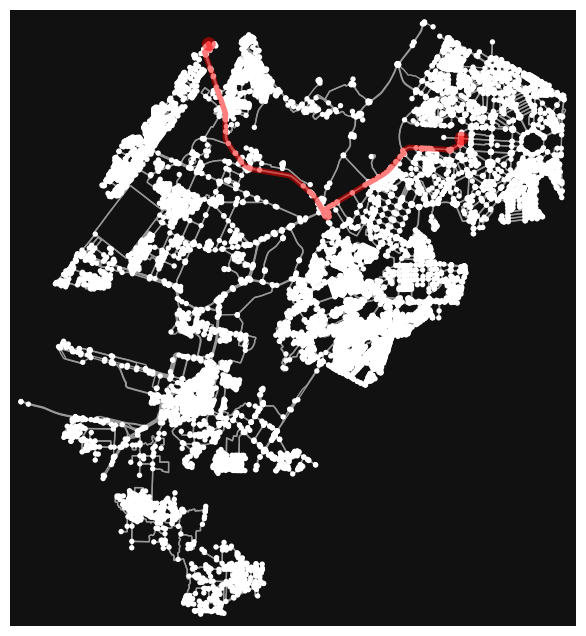

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
ox.plot_graph_route(graph, route)

In [6]:
for u, v, k, data in graph.edges(keys=True, data=True):
    base_length = data.get('length', 1)

    # Simulated traffic factor (replace later with real mapping)
    traffic_factor = 1.2  

    data['traffic_weight'] = base_length * traffic_factor

In [7]:
route_traffic = nx.shortest_path(
    graph, orig_node, dest_node, weight='traffic_weight'
)

In [8]:
for u, v, k, data in graph.edges(keys=True, data=True):
    risk_factor = 1.1  # simulate

    data['risk_weight'] = data.get('length', 1) * risk_factor

In [9]:
for u, v, k, data in graph.edges(keys=True, data=True):
    data['final_weight'] = (
        data.get('traffic_weight', 1) * 0.6 +
        data.get('risk_weight', 1) * 0.4
    )

In [10]:
route_final = nx.shortest_path(
    graph, orig_node, dest_node, weight='final_weight'
)

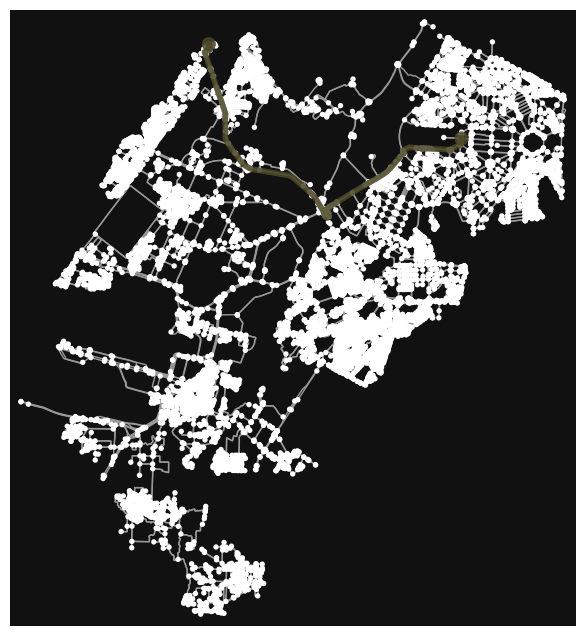

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
ox.plot_graph_routes(
    graph,
    [route, route_traffic, route_final],
    route_colors=['blue', 'red', 'green']
)